## Pipeline `fft_feature_engineering` — Features espectrais e rolling para detecção de falha

**Pipeline:** `fft_feature_engineering`  
**Kedro node:** `engineer_fft_features_for_all_flights_node`  
**Entrada:** `fft_prepared_flights` → `data/03_primary/fft/`  
**Saída:** `fft_feature_engineered_flights` → `data/04_feature/fft/`

---

Este notebook é o análogo do `02_00` para o subconjunto FFT preparado em `01_01`.  
Opera sobre 7 sinais com vínculo físico direto à frequência de rotação do motor:

| Sinal | Tipo | Relação com falha de motor |
|---|---|---|
| `imu_accel_x/y/z` | Vibração estrutural | Oscilações na frequência de rotação do motor/hélice |
| `mag_x/y/z` | Campo EM | Campo dos enrolamentos do motor + rotação da hélice |
| `aspd_meas` | Aerodinâmica | Ripple de thrust antes da falha completa |

Para cada sinal, duas famílias de features são geradas:

| Família | Descriptores | Janelas | O que captura |
|---|---|---|---|
| Rolling statistics | `mean`, `std`, `slope` | [50, 100, 200] amostras | Tendências de amplitude no tempo |
| FFT spectral | `peak_power`, `entropy`, `high_ratio` | [500, 1000, 2000] amostras | Estrutura espectral — concentração e distribuição de energia por frequência |

> **Para rodar no Kedro:** `kedro run --pipeline=fft_feature_engineering`

## Imports e parâmetros (fft_feature_engineering)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aeroespacial_2.pipelines.feature_engineering.nodes import (
    compute_fft_features,
    compute_rolling_features,
)
from aeroespacial_2.pipelines.fft_feature_engineering.nodes import (
    FFT_PIPELINE_SIGNALS,
    engineer_fft_features,
)

# Espelha conf/base/parameters.yml → fft_feature_engineering
FLIGHT_NAME = "carbonZ_2018-07-18-15-53-31_1_engine_failure"
PREPARED_DATA = "../../data/03_primary/fft/carbonZ_2018-07-18-15-53-31_1_engine_failure.csv"
ROLLING_WINDOWS = [50, 100, 200]    # amostras: ~0.25 s, ~0.5 s, ~1 s a ~200 Hz
FFT_WINDOWS = [500, 1000, 2000]     # amostras: ~2.5 s, ~5 s, ~10 s a ~200 Hz

## Carregamento e overview do voo

In [2]:
df_prepared = pd.read_csv(PREPARED_DATA)

dt = df_prepared["timestamp"].diff().median()
duration = df_prepared["timestamp"].max()
fault_onset = df_prepared.loc[df_prepared["target_fault"] == 1, "timestamp"].min()
fault_frac = (df_prepared["target_fault"] == 1).mean() * 100

print(f"Shape: {df_prepared.shape}")
print(f"Taxa de amostragem estimada: {1/dt:.1f} Hz  (dt mediano = {dt*1000:.2f} ms)")
print(f"Duração total do voo: {duration:.1f} s")
print(f"Início da falha: {fault_onset:.1f} s ({fault_frac:.1f}% do voo em falha)")
print()
print(f"Janelas rolling {ROLLING_WINDOWS} amostras ≈ {[round(w*dt, 2) for w in ROLLING_WINDOWS]} s")
print(f"Janelas FFT     {FFT_WINDOWS} amostras ≈ {[round(w*dt, 2) for w in FFT_WINDOWS]} s")
print()
print(f"Colunas de entrada ({len(df_prepared.columns)}):")
for col in df_prepared.columns:
    s = df_prepared[col].std() if col not in {"timestamp", "target_fault"} else float("nan")
    tag = "(protegida)" if col in {"timestamp", "target_fault"} else f"std={s:.4f}"
    print(f"  {col:<20} {tag}")

Shape: (25994, 10)
Taxa de amostragem estimada: 523.5 Hz  (dt mediano = 1.91 ms)
Duração total do voo: 131.4 s
Início da falha: 115.3 s (12.4% do voo em falha)

Janelas rolling [50, 100, 200] amostras ≈ [np.float64(0.1), np.float64(0.19), np.float64(0.38)] s
Janelas FFT     [500, 1000, 2000] amostras ≈ [np.float64(0.96), np.float64(1.91), np.float64(3.82)] s

Colunas de entrada (10):
  timestamp            (protegida)
  target_fault         (protegida)
  alt_global           std=4.2294
  imu_accel_x          std=0.5583
  imu_accel_y          std=0.3000
  imu_accel_z          std=2.2661
  mag_x                std=119214.3965
  mag_y                std=186923.2615
  mag_z                std=59025.5867
  aspd_meas            std=1.8364


## Feature 1 — Estatísticas de janela temporal (rolling)

Valores instantâneos capturam o estado *agora*. Estatísticas de janela capturam *tendências*.
Para cada sinal FFT, calculamos:
- **mean**: nível médio do sinal na janela — remove ruído de alta frequência
- **std**: variabilidade local — tipicamente aumenta no início da falha
- **slope**: taxa de variação média na janela [unidade/s] — detecta tendências graduais

Exemplo físico para `aspd_meas`:
- **mean**: proxy do nível de thrust sustentado — cai com a perda de empuxo
- **std**: estabilidade da velocidade — aumenta com instabilidade pós-falha
- **slope**: detecta a desaceleração gradual após a falha do motor

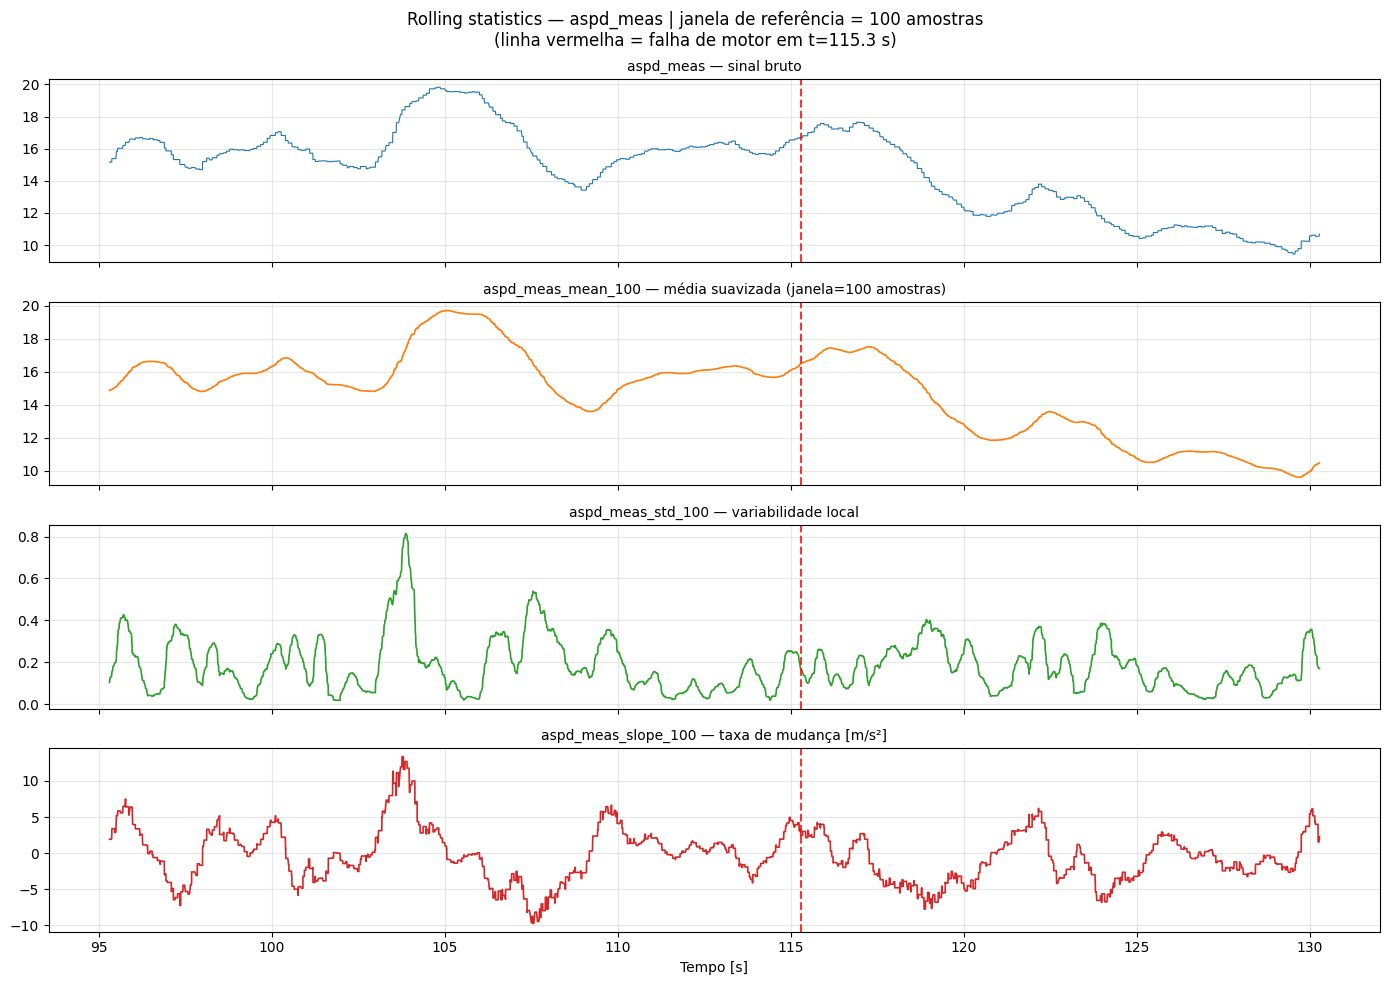

Shape após compute_rolling_features: (25994, 73)
Features rolling criadas: 63  (7 sinais × 3 janelas × 3 stats)


In [3]:
signals = [f for f in FFT_PIPELINE_SIGNALS if f in df_prepared.columns]
df_roll = compute_rolling_features(df_prepared, ROLLING_WINDOWS, signals)

# Janela de visualização: 20 s antes até 15 s depois da falha
t0, t1 = fault_onset - 20, fault_onset + 15
view = df_roll[(df_roll["timestamp"] >= t0) & (df_roll["timestamp"] <= t1)]

# Visualiza rolling stats para aspd_meas (sinal com tendência temporal mais clara)
w_ref = ROLLING_WINDOWS[1]  # janela do meio para referência
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(view["timestamp"], view["aspd_meas"], color="tab:blue", linewidth=0.8, label="raw")
axes[0].set_title(f"aspd_meas — sinal bruto", fontsize=10)

axes[1].plot(view["timestamp"], view[f"aspd_meas_mean_{w_ref}"], color="tab:orange", linewidth=1.2)
axes[1].set_title(f"aspd_meas_mean_{w_ref} — média suavizada (janela={w_ref} amostras)", fontsize=10)

axes[2].plot(view["timestamp"], view[f"aspd_meas_std_{w_ref}"], color="tab:green", linewidth=1.2)
axes[2].set_title(f"aspd_meas_std_{w_ref} — variabilidade local", fontsize=10)

axes[3].plot(view["timestamp"], view[f"aspd_meas_slope_{w_ref}"], color="tab:red", linewidth=1.2)
axes[3].set_title(f"aspd_meas_slope_{w_ref} — taxa de mudança [m/s²]", fontsize=10)

for ax in axes:
    ax.axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", alpha=0.8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tempo [s]")
plt.suptitle(
    f"Rolling statistics — aspd_meas | janela de referência = {w_ref} amostras\n"
    f"(linha vermelha = falha de motor em t={fault_onset:.1f} s)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

roll_cols = [c for c in df_roll.columns if any(
    c.startswith(f"{s}_mean") or c.startswith(f"{s}_std") or c.startswith(f"{s}_slope")
    for s in signals
)]
print(f"Shape após compute_rolling_features: {df_roll.shape}")
print(f"Features rolling criadas: {len(roll_cols)}  ({len(signals)} sinais × {len(ROLLING_WINDOWS)} janelas × 3 stats)")

## Feature 2 — Espectro de frequências (FFT rolling)

As features de rolling capturam *quanto* um sinal muda. O domínio de frequência captura
*como* ele oscila — informação invisível na amplitude instantânea.

Para cada sinal e janela, três descritores espectrais são extraídos do espectro de magnitude:

| Descriptor | Fórmula | Interpretação física |
|---|---|---|
| `fft_peak_power` | max(|FFT[1:]|²) | Potência da frequência dominante (não-DC). Aumenta quando oscilações periódicas aparecem |
| `fft_entropy` | −Σ p log(p) / log(N) ∈ [0,1] | 0 = senoide pura (energia em 1 freq.). 1 = ruído branco. Falha → transição de estruturado para caótico |
| `fft_high_ratio` | P(f > f_mid) / P_total | Fração de potência em alta frequência. Vibração do motor injeta energia acima da banda de manobras |

**Por que janelas grandes (500–2000 amostras)?**  
Precursores de falha do motor aparecem a 0.1–2 Hz. Janelas de 500 amostras a ~200 Hz
cobrem ~2.5 s, suficiente para resolver componentes espectrais em ~0.4 Hz.  
Janelas pequenas (50–200) só capturam ruído de alta frequência.

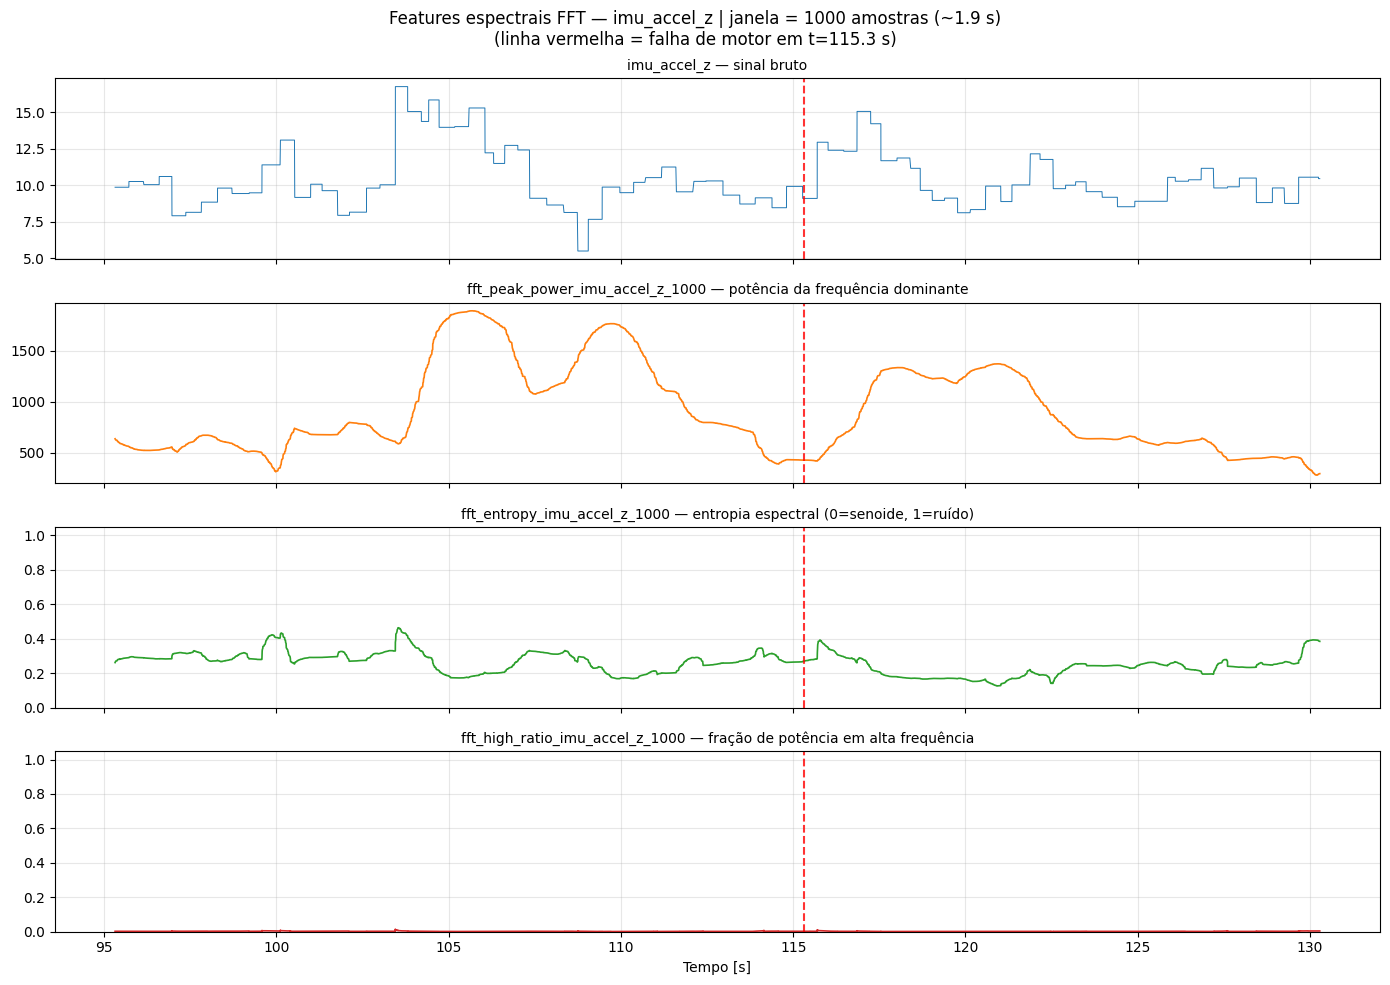

Shape após compute_fft_features: (25994, 73)
Features FFT criadas: 63  (7 sinais × 3 janelas × 3 descritores)


In [4]:
df_fft = compute_fft_features(df_prepared, FFT_WINDOWS, signals)

view_fft = df_fft[(df_fft["timestamp"] >= t0) & (df_fft["timestamp"] <= t1)]

# Visualiza os 3 descritores para imu_accel_z (sinal de vibração mais relevante — eixo da gravidade)
w_ref = FFT_WINDOWS[1]  # janela do meio
sinal_ref = "imu_accel_z"

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(view_fft["timestamp"], view_fft[sinal_ref], color="tab:blue", linewidth=0.7, label="raw")
axes[0].set_title(f"{sinal_ref} — sinal bruto", fontsize=10)

axes[1].plot(view_fft["timestamp"], view_fft[f"fft_peak_power_{sinal_ref}_{w_ref}"],
             color="tab:orange", linewidth=1.2)
axes[1].set_title(f"fft_peak_power_{sinal_ref}_{w_ref} — potência da frequência dominante", fontsize=10)

axes[2].plot(view_fft["timestamp"], view_fft[f"fft_entropy_{sinal_ref}_{w_ref}"],
             color="tab:green", linewidth=1.2)
axes[2].set_ylim(0, 1.05)
axes[2].set_title(f"fft_entropy_{sinal_ref}_{w_ref} — entropia espectral (0=senoide, 1=ruído)", fontsize=10)

axes[3].plot(view_fft["timestamp"], view_fft[f"fft_high_ratio_{sinal_ref}_{w_ref}"],
             color="tab:red", linewidth=1.2)
axes[3].set_ylim(0, 1.05)
axes[3].set_title(f"fft_high_ratio_{sinal_ref}_{w_ref} — fração de potência em alta frequência", fontsize=10)

for ax in axes:
    ax.axvline(fault_onset, color="red", linewidth=1.5, linestyle="--", alpha=0.8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Tempo [s]")
plt.suptitle(
    f"Features espectrais FFT — {sinal_ref} | janela = {w_ref} amostras (~{w_ref*dt:.1f} s)\n"
    f"(linha vermelha = falha de motor em t={fault_onset:.1f} s)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

fft_cols = [c for c in df_fft.columns if c.startswith("fft_")]
print(f"Shape após compute_fft_features: {df_fft.shape}")
print(f"Features FFT criadas: {len(fft_cols)}  ({len(signals)} sinais × {len(FFT_WINDOWS)} janelas × 3 descritores)")

## Comparação espectral entre todos os sinais FFT

Visualiza `fft_peak_power` e `fft_entropy` de cada sinal em torno do evento de falha.
Objetivo: identificar quais sinais apresentam a assinatura espectral mais clara.

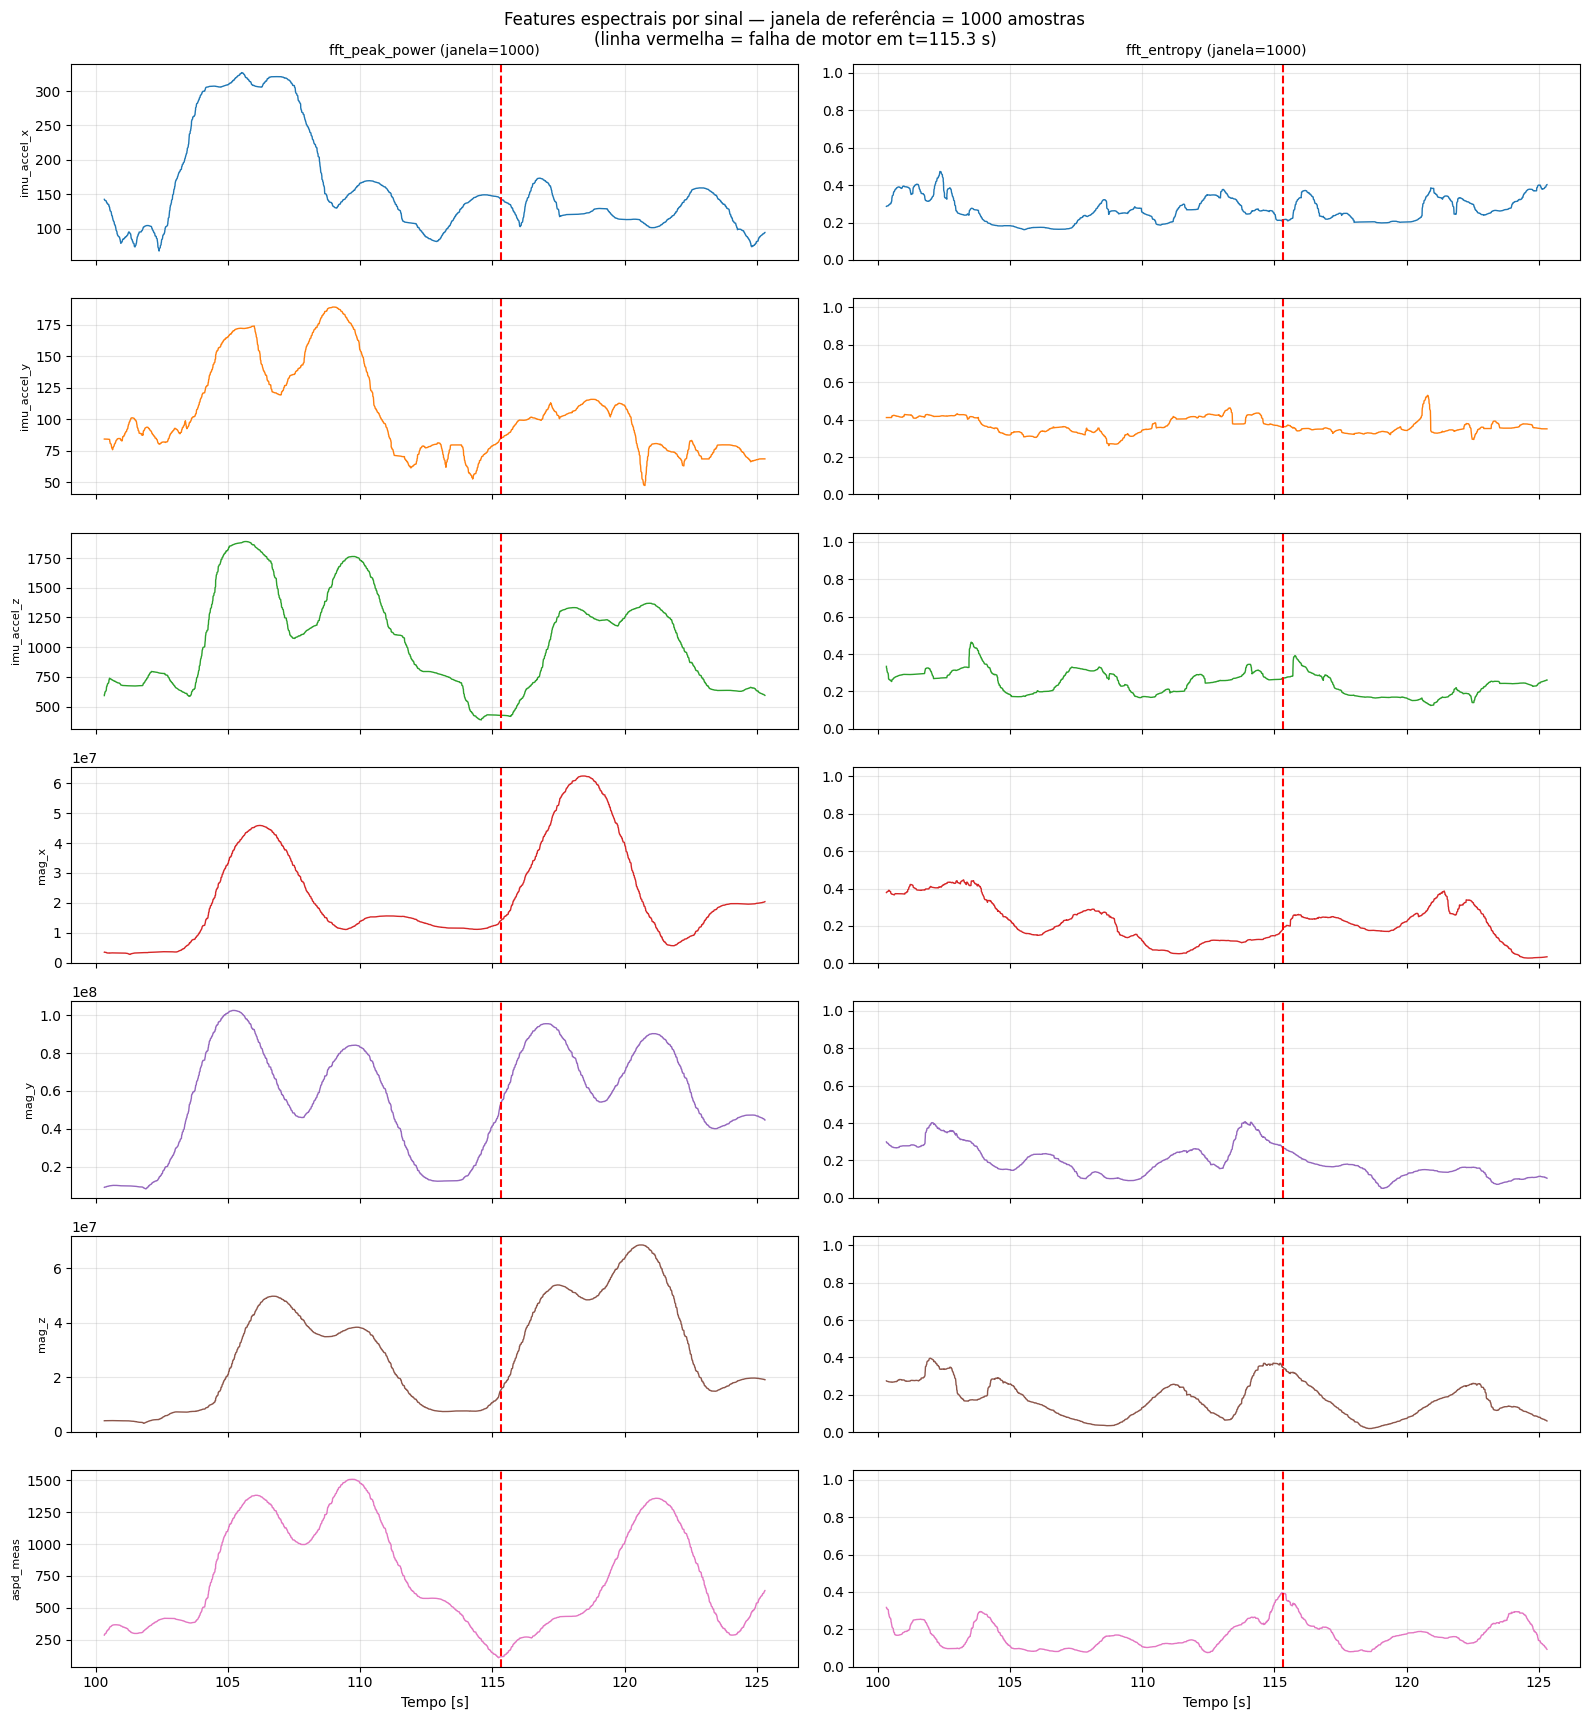

In [5]:
w_ref = FFT_WINDOWS[1]
t0_close, t1_close = fault_onset - 15, fault_onset + 10
close = df_fft[(df_fft["timestamp"] >= t0_close) & (df_fft["timestamp"] <= t1_close)]

cores = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

fig, axes = plt.subplots(len(signals), 2, figsize=(16, 2.5 * len(signals)), sharex=True)

for i, (sinal, cor) in enumerate(zip(signals, cores)):
    # Peak power
    axes[i, 0].plot(close["timestamp"], close[f"fft_peak_power_{sinal}_{w_ref}"],
                    color=cor, linewidth=1.0)
    axes[i, 0].axvline(fault_onset, color="red", lw=1.5, ls="--")
    axes[i, 0].set_ylabel(sinal, fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title(f"fft_peak_power (janela={w_ref})", fontsize=10)

    # Entropy
    axes[i, 1].plot(close["timestamp"], close[f"fft_entropy_{sinal}_{w_ref}"],
                    color=cor, linewidth=1.0)
    axes[i, 1].axvline(fault_onset, color="red", lw=1.5, ls="--")
    axes[i, 1].set_ylim(0, 1.05)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title(f"fft_entropy (janela={w_ref})", fontsize=10)

for ax in axes[-1]:
    ax.set_xlabel("Tempo [s]")

plt.suptitle(
    f"Features espectrais por sinal — janela de referência = {w_ref} amostras\n"
    f"(linha vermelha = falha de motor em t={fault_onset:.1f} s)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Pipeline completo — `engineer_fft_features`

Aqui aplicamos a função de nível de voo que combina rolling + FFT em uma única chamada,
espelhando exatamente o que o pipeline Kedro executa para cada partição.

In [6]:
df_feat = engineer_fft_features(df_prepared, ROLLING_WINDOWS, FFT_WINDOWS)

original_cols = set(df_prepared.columns)
new_cols = [c for c in df_feat.columns if c not in original_cols]
rolling_new = [c for c in new_cols if not c.startswith("fft_")]
fft_new = [c for c in new_cols if c.startswith("fft_")]

print(f"Shape original  (df_prepared): {df_prepared.shape}")
print(f"Shape final     (df_feat):     {df_feat.shape}")
print(f"Features novas:                {len(new_cols)}")
print(f"  → rolling:  {len(rolling_new)}  ({len(signals)} sinais × {len(ROLLING_WINDOWS)} janelas × 3 stats)")
print(f"  → fft:      {len(fft_new)}  ({len(signals)} sinais × {len(FFT_WINDOWS)} janelas × 3 descritores)")

Shape original  (df_prepared): (25994, 10)
Shape final     (df_feat):     (25994, 136)
Features novas:                126
  → rolling:  63  (7 sinais × 3 janelas × 3 stats)
  → fft:      63  (7 sinais × 3 janelas × 3 descritores)


## Resultado — shape final e colunas criadas

In [7]:
PROTECTED = {"timestamp", "target_fault"}

print(f"{'Feature':<48} {'std':>12}")
print("-" * 62)
for col in df_feat.columns:
    if col in PROTECTED:
        print(f"  {col:<46} {'(protegida)':>12}")
    else:
        print(f"  {col:<46} {df_feat[col].std():>12.4f}")

Feature                                                   std
--------------------------------------------------------------
  timestamp                                       (protegida)
  target_fault                                    (protegida)
  alt_global                                           4.2294
  imu_accel_x                                          0.5583
  imu_accel_y                                          0.3000
  imu_accel_z                                          2.2661
  mag_x                                           119214.3965
  mag_y                                           186923.2615
  mag_z                                            59025.5867
  aspd_meas                                            1.8364
  imu_accel_x_mean_50                                  0.5493
  imu_accel_x_std_50                                   0.0845
  imu_accel_x_slope_50                                 2.5754
  imu_accel_x_mean_100                                 0.5402
  imu_a

## Próximos passos

O DataFrame `df_feat` (salvo em `data/04_feature/fft/`) contém as features espectrais
e de rolling prontas para treino de modelo.

Para ajustar os parâmetros, edite `conf/base/parameters.yml`:
```yaml
fft_feature_engineering:
  rolling_windows: [50, 100, 200]   # aumentar para janelas mais suaves
  fft_windows: [500, 1000, 2000]    # janelas para features espectrais
```

---
**Para rodar o pipeline completo FFT:**
```bash
kedro run --pipeline=fft_ingestion
kedro run --pipeline=fft_data_preparation
kedro run --pipeline=fft_feature_engineering
```